In [1]:
import hydra
from omegaconf import OmegaConf
print('hydra imported')
import os
import torch
from tqdm.auto import tqdm
from datasets.pfams import PfamDataset
print('dataset class imported')
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np
from transformers import AutoTokenizer
from transformers import EsmModel

# ignore FutureWarnings
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

from geomloss import SamplesLoss
from sklearn.neighbors import NearestNeighbors

hydra imported
dataset class imported


In [2]:
def prepare_batch(samples_list, device):
    batch = {}
    for key in samples_list[0].keys():
        values = [s[key] for s in samples_list]
        if isinstance(values[0], torch.Tensor):
            batch[key] = torch.stack(values).to(device)
        elif isinstance(values[0], (int, float)):
            batch[key] = torch.tensor(values).to(device)
        else:
            batch[key] = values
    return batch


def get_esm_embeddings(esm_model, input_ids, attention_mask):
    """Compute mean-pooled ESM embeddings."""
    with torch.no_grad():
        hidden_states = esm_model(input_ids, attention_mask=attention_mask).last_hidden_state
    mask = attention_mask.unsqueeze(-1).float()
    return (hidden_states * mask).sum(dim=1) / mask.sum(dim=1).clamp(min=1e-9)


def retokenize_sequences(sequences, esm_tokenizer, max_length=64):
    """
    Decode and retokenize sequences. probably a bit silly
    """
    if sequences.dim() == 2:
        sequences = sequences.unsqueeze(1)
    
    batch_size, num_samples, seq_len = sequences.shape
    
    all_seqs = []
    for b in range(batch_size):
        for s in range(num_samples):
            seq_ids = sequences[b, s].cpu().tolist()
            seq_str = esm_tokenizer.decode(seq_ids, skip_special_tokens=False)
            all_seqs.append(seq_str)
    
    tokens = esm_tokenizer(
        all_seqs, 
        return_tensors='pt',
        padding=True, 
        truncation=True, 
        max_length=max_length
    )
    return tokens['input_ids'], tokens['attention_mask']

def sample_anytoany(encoder, generator, source_batch, target_batch, num_samples):
    with torch.no_grad():
        source_embedding = encoder(source_batch)
        target_embedding = encoder(target_batch)
        sampled_sequences = generator.sample(
            source_batch, source_embedding, target_embedding, 
            num_samples=num_samples
        )
    return sampled_sequences


def sample_onehot(encoder, generator, source_batch, target_batch, 
                  esm_model, nbrs, train_keys, num_samples, device):
    batch_size = source_batch['esm_input_ids'].size(0)
    
    with torch.no_grad():
        # Compute source ESM embeddings
        src_ids = source_batch['esm_input_ids'].view(-1, source_batch['esm_input_ids'].size(-1))
        src_mask = source_batch['esm_attention_mask'].view(-1, source_batch['esm_attention_mask'].size(-1))
        source_embs = get_esm_embeddings(esm_model, src_ids, src_mask)
        source_embs = source_embs.view(batch_size, -1, source_embs.size(-1)).mean(dim=1)
        
        # Compute target ESM embeddings
        tgt_ids = target_batch['esm_input_ids'].view(-1, target_batch['esm_input_ids'].size(-1))
        tgt_mask = target_batch['esm_attention_mask'].view(-1, target_batch['esm_attention_mask'].size(-1))
        target_embs = get_esm_embeddings(esm_model, tgt_ids, tgt_mask)
        target_embs = target_embs.view(batch_size, -1, target_embs.size(-1)).mean(dim=1)
        
        # Find nearest neighbors
        source_nn_indices = nbrs.kneighbors(source_embs.cpu().numpy())[1][:, 1]
        target_nn_indices = nbrs.kneighbors(target_embs.cpu().numpy())[1][:, 1]
        
        source_nn_keys = [train_keys[idx] for idx in source_nn_indices]
        target_nn_keys = [train_keys[idx] for idx in target_nn_indices]
        
        # Get one-hot encodings
        source_onehot = encoder({'idx': torch.tensor(source_nn_keys, device=device)})
        target_onehot = encoder({'idx': torch.tensor(target_nn_keys, device=device)})
        
        sampled_sequences = generator.sample(
            source_batch, source_onehot, target_onehot,
            num_samples=num_samples
        )
    return sampled_sequences


def compute_energy_distance(sampled_embs, target_embs):
    """Compute energy distance between two sets of embeddings."""
    loss_fn = SamplesLoss("energy", p=2)
    return loss_fn(sampled_embs, target_embs).item()


def compute_sliced_wasserstein(sampled_embs, target_embs):
    """Compute Sinkhorn (approximated Wasserstein) distance."""
    loss_fn = SamplesLoss("sinkhorn", blur=0.01, scaling=0.9)
    return loss_fn(sampled_embs, target_embs).item()


METRIC_FUNCTIONS = {
    'energy': compute_energy_distance,
    'sliced_wasserstein': compute_sliced_wasserstein,
}



def evaluate_distribution_matching(
    encoder, 
    generator, 
    dataset, 
    esm_model, 
    esm_tokenizer,
    model_type='anytoany',
    num_pairs=100,
    num_samples=16,
    metrics=('energy',),
    nbrs=None,
    train_keys=None,
    device='cuda',
    batch_size=8
):
    """
    Evaluate distribution matching quality.
    
    Args:
        encoder: Encoder model
        generator: Generator model
        dataset: Evaluation dataset
        esm_model: Pretrained ESM model for embeddings
        esm_tokenizer: ESM tokenizer
        model_type: 'anytoany' or 'onehot'
        num_pairs: Number of source-target pairs to evaluate
        num_samples: Number of samples to generate per pair
        metrics: Tuple of metric names ('energy', 'sliced_wasserstein')
        nbrs: NearestNeighbors model (required for 'onehot')
        train_keys: Sorted list of training keys (required for 'onehot')
        device: Device to use
        batch_size: Batch size for processing
    
    Returns:
        Dict with mean and SEM for each metric
    """
    # Validate inputs
    if model_type == 'onehot':
        if nbrs is None or train_keys is None:
            raise ValueError("nbrs and train_keys are required for onehot model_type")
    
    if model_type not in ('anytoany', 'onehot'):
        raise ValueError(f"Unknown model_type: {model_type}")
    
    for metric in metrics:
        if metric not in METRIC_FUNCTIONS:
            raise ValueError(f"Unknown metric: {metric}. Available: {list(METRIC_FUNCTIONS.keys())}")
    
    results = {metric: [] for metric in metrics}
    num_batches = (num_pairs + batch_size - 1) // batch_size
    
    for batch_idx in tqdm(range(num_batches), desc="Evaluating"):
        start_idx = batch_idx * batch_size
        end_idx = min(start_idx + batch_size, num_pairs)
        current_batch_size = end_idx - start_idx
        
        # Collect samples for batch
        source_samples_list = []
        target_samples_list = []
        for idx in range(start_idx, end_idx):
            pair = dataset[idx]
            source_samples_list.append(pair['source_samples'])
            target_samples_list.append(pair['target_samples'])
        
        source_batch = prepare_batch(source_samples_list, device)
        target_batch = prepare_batch(target_samples_list, device)
        
        # Generate samples
        if model_type == 'anytoany':
            sampled_sequences = sample_anytoany(
                encoder, generator, source_batch, target_batch, num_samples
            )
        else:  # onehot
            sampled_sequences = sample_onehot(
                encoder, generator, source_batch, target_batch,
                esm_model, nbrs, train_keys, num_samples, device
            )
        
        # Retokenize and compute embeddings for sampled sequences
        sampled_ids, sampled_mask = retokenize_sequences(sampled_sequences, esm_tokenizer)
        sampled_ids = sampled_ids.to(device)
        sampled_mask = sampled_mask.to(device)
        
        with torch.no_grad():
            sampled_embs = get_esm_embeddings(esm_model, sampled_ids, sampled_mask)
            sampled_embs = sampled_embs.view(current_batch_size, num_samples, -1)
            
            # Compute embeddings for target sequences
            target_ids = target_batch['esm_input_ids'].view(-1, target_batch['esm_input_ids'].size(-1))
            target_mask = target_batch['esm_attention_mask'].view(-1, target_batch['esm_attention_mask'].size(-1))
            target_embs = get_esm_embeddings(esm_model, target_ids, target_mask)
            target_embs = target_embs.view(current_batch_size, num_samples, -1)
        
        # Compute metrics for each pair in batch
        for i in range(current_batch_size):
            for metric in metrics:
                metric_fn = METRIC_FUNCTIONS[metric]
                results[metric].append(metric_fn(sampled_embs[i], target_embs[i]))
    
    # Aggregate results
    output = {}
    for metric in metrics:
        values = np.array(results[metric])
        output[f'{metric}_mean'] = values.mean()
        output[f'{metric}_sem'] = values.std() / np.sqrt(len(values))
    
    return output

In [22]:
class ModelConfig:
    """Configuration for a model pair (onehot + anytoany)"""
    def __init__(self, name, onehot_dir, anytoany_dir, train_data_file, eval_data_file, 
                 max_pfams=None, num_train_embeddings=750, data_dir='/orcd/data/omarabu/001/gokul/DistributionEmbeddings/data/pfam'):
        self.name = name
        self.onehot_dir = onehot_dir
        self.anytoany_dir = anytoany_dir
        self.train_data_file = train_data_file
        self.eval_data_file = eval_data_file
        self.num_train_embeddings = num_train_embeddings
        self.data_dir = data_dir
        self.max_pfams = max_pfams


def load_model_pair(config, device='cuda'):
    """Load both onehot and anytoany models from a ModelConfig"""
    base_dir = '/orcd/data/omarabu/001/gokul/CoupledDistributionEmbeddings/outputs/'
    
    models = {}
    
    # Load onehot model
    onehot_path = os.path.join(base_dir, config.onehot_dir)
    config_path = os.path.join(onehot_path, 'config.yaml')
    if not os.path.exists(config_path):
        raise FileNotFoundError(f"Config not found at {config_path}")
    
    onehot_config = OmegaConf.load(config_path)
    models['onehot_encoder'] = hydra.utils.instantiate(onehot_config.encoder)
    models['onehot_generator'] = hydra.utils.instantiate(onehot_config.generator)
    
    checkpoint = torch.load(os.path.join(onehot_path, 'checkpoint_epoch_600.pt'), 
                           map_location=device, weights_only=False)
    models['onehot_encoder'].load_state_dict(checkpoint['encoder_state_dict'])
    models['onehot_generator'].load_state_dict(checkpoint['generator_state_dict'])
    models['onehot_encoder'].to(device).eval()
    models['onehot_generator'].to(device).eval()
    
    # Load anytoany model
    anytoany_path = os.path.join(base_dir, config.anytoany_dir)
    config_path = os.path.join(anytoany_path, 'config.yaml')
    if not os.path.exists(config_path):
        raise FileNotFoundError(f"Config not found at {config_path}")
    
    anytoany_config = OmegaConf.load(config_path)
    models['anytoany_encoder'] = hydra.utils.instantiate(anytoany_config.encoder)
    models['anytoany_generator'] = hydra.utils.instantiate(anytoany_config.generator)
    
    checkpoint = torch.load(os.path.join(anytoany_path, 'checkpoint_epoch_600.pt'), 
                           map_location=device, weights_only=False)

    models['anytoany_encoder'].load_state_dict(checkpoint['encoder_state_dict'])
    models['anytoany_generator'].load_state_dict(checkpoint['generator_state_dict'])
    models['anytoany_encoder'].to(device).eval()
    models['anytoany_generator'].to(device).eval()
    
    return models


def load_datasets(config, set_size=16, max_length=64, max_pfams=None):
    """Load train and eval datasets from a ModelConfig"""
    train_dataset = PfamDataset(
        data_dir=config.data_dir,
        data_file=config.train_data_file,
        tokenize=False,
        set_size=set_size,
        max_length=max_length,
        max_pfams=max_pfams,
        base_dir=''
    )
    
    eval_dataset = PfamDataset(
        data_dir=config.data_dir,
        data_file=config.eval_data_file,
        tokenize=False,
        set_size=set_size,
        max_length=max_length,
        max_pfams=max_pfams,
        base_dir=''
    )
    
    return train_dataset, eval_dataset


def build_train_embeddings(train_dataset, esm_model, num_embeddings, device='cuda'):
    """Build training embeddings for nearest neighbor lookup (onehot model)"""
    train_source_embeddings = {}
    p = 0
    
    pbar = tqdm(total=num_embeddings, desc="Building train embeddings")
    while len(train_source_embeddings) < num_embeddings:
        batch = train_dataset[p]
        if batch['source_samples']['idx'] in train_source_embeddings.keys():
            p += 1
            continue
        
        source_samples = batch['source_samples']
        for key in source_samples.keys():
            if isinstance(source_samples[key], torch.Tensor):
                source_samples[key] = source_samples[key].unsqueeze(0).to(device)
        
        with torch.no_grad():
            x = esm_model(source_samples['esm_input_ids'].squeeze(0),
                         attention_mask=source_samples['esm_attention_mask'].squeeze(0)).last_hidden_state
            mask = source_samples['esm_attention_mask'].unsqueeze(-1).float()
            source_embedding = (x * mask).sum(1) / mask.sum(1).clamp(min=1e-9)
            source_embedding = source_embedding.mean(axis=1)
            train_source_embeddings[batch['source_samples']['idx']] = source_embedding
        
        p += 1
        pbar.update(1)
    
    pbar.close()
    
    # Build nearest neighbors index
    train_embs_vec = torch.cat([train_source_embeddings[k] for k in sorted(train_source_embeddings.keys())], dim=0).cpu().numpy()
    nbrs = NearestNeighbors(n_neighbors=2, algorithm='ball_tree').fit(train_embs_vec)
    train_keys = sorted(list(train_source_embeddings.keys()))
    
    return nbrs, train_keys


def evaluate_model_config(config, esm_model, esm_tokenizer, num_pairs=100, 
                         num_samples=16, metrics=('energy', 'sliced_wasserstein'), 
                         device='cuda', set_size=16, max_length=64):
    """
    Complete evaluation pipeline for a ModelConfig
    
    Returns:
        dict with results for both onehot and anytoany models
    """
    print(f"Evaluating: {config.name}")
    
    # Load models
    print("Loading models...")
    models = load_model_pair(config, device)
    
    # Load datasets
    print("Loading datasets...")
    train_dataset, eval_dataset = load_datasets(config, set_size, max_length, config.max_pfams)
    
    # Build train embeddings for onehot model
    print("Building training embeddings...")
    nbrs, train_keys = build_train_embeddings(
        train_dataset, esm_model, config.num_train_embeddings, device
    )
    
    # Evaluate anytoany model
    print("\nEvaluating any-to-any model...")
    results_anytoany = evaluate_distribution_matching(
        models['anytoany_encoder'], models['anytoany_generator'], 
        eval_dataset, esm_model, esm_tokenizer,
        model_type='anytoany', num_pairs=num_pairs, num_samples=num_samples,
        metrics=metrics, device=device
    )
    
    # Evaluate onehot model
    print("Evaluating onehot model...")
    results_onehot = evaluate_distribution_matching(
        models['onehot_encoder'], models['onehot_generator'], 
        eval_dataset, esm_model, esm_tokenizer,
        model_type='onehot', num_pairs=num_pairs, num_samples=num_samples,
        metrics=metrics, nbrs=nbrs, train_keys=train_keys, device=device
    )
    
    # Print results
    print(f"\n{config.name} Results:")
    print("-" * 60)
    for metric in metrics:
        print(f"  any-to-any {metric}: {results_anytoany[f'{metric}_mean']:.4f} \pm {results_anytoany[f'{metric}_sem']:.4f}")
        print(f"  onehot {metric}: {results_onehot[f'{metric}_mean']:.4f} \pm {results_onehot[f'{metric}_sem']:.4f}")
    
    return {
        'anytoany': results_anytoany,
        'onehot': results_onehot,
        'config': config
    }

In [23]:
configs = os.listdir('/orcd/data/omarabu/001/gokul/CoupledDistributionEmbeddings/outputs/')
onehot_configs = [c for c in configs if c.startswith('pfam_onehot_')]
anytoany_configs = [c for c in configs if c.startswith('pfam_esm_dfm_')]

model_configs = []

for k in ['1e1', '1e2', '1e3', '1e4']:
    onehot_dir = [c for c in onehot_configs if f'_{k}_' in c][0]
    anytoany_dir = [c for c in anytoany_configs if f'_{k}_' in c][0]
    train_data_file = f'pfam_tokenized_data_l64_full.pt'
    eval_data_file = 'eval_pfam_tokenized_data_l64_full.pt'
    num_train_embeddings = int(float(k))
    
    model_configs.append(
        ModelConfig(
            name=f'k={k}',
            onehot_dir=onehot_dir,
            anytoany_dir=anytoany_dir,
            train_data_file=train_data_file,
            eval_data_file=eval_data_file,
            num_train_embeddings=num_train_embeddings if k != '1e4' else 8000,
            max_pfams=int(float(k)) if k != '1e4' else 8000
        )
    )

# model_configs = [
#     ModelConfig(
#         name="k=1e1",
#         onehot_dir="pfam_onehot_1e1_6bd697dbc161c59e2a86d97571243866",
#         anytoany_dir="pfam_esm_dfm_1e1_d922cc6c918b6480166a947c830be50c",
#         train_data_file="pfam_tokenized_data_l64_1e1_small.pt",
#         eval_data_file="eval_pfam_tokenized_data_l64_full.pt",
#         num_train_embeddings=7
#     ),
#     ModelConfig(
#         name="k=1e2",
#         onehot_dir="pfam_onehot_1e2_18e91786b3b4aff0e99e2c1953666381",
#         anytoany_dir="pfam_esm_dfm_584058a73b541ac031541646ef281ea4",
#         train_data_file="pfam_tokenized_data_l64_1e2_small.pt",
#         eval_data_file="eval_pfam_tokenized_data_l64_full.pt",
#         num_train_embeddings=75
#     ),
#     ModelConfig(
#         name="k=1e3",
#         onehot_dir="pfam_onehot_1e3_7452dcc1343066e88dfaab0b5355d012",
#         anytoany_dir="pfam_esm_dfm_1e3_91ecf84ef82f542c759188944c42fd30",
#         train_data_file="pfam_tokenized_data_l64_1e3_small.pt",
#         eval_data_file="eval_pfam_tokenized_data_l64_full.pt",
#         num_train_embeddings=750
#     ),
#     ModelConfig(
#         name="k=1e4",
#         onehot_dir="pfam_onehot_1e4_3b474421e59ef501ae348f1f3727057e",
#         anytoany_dir="pfam_esm_dfm_6c61ec377c95ab55c2b7416301172534",  # Update with actual anytoany dir
#         train_data_file="pfam_tokenized_data_l64_1e4_small.pt",
#         eval_data_file="eval_pfam_tokenized_data_l64_1e4_small.pt",
#         num_train_embeddings=7500
#     ),
# ]

In [24]:
device = 'cuda'
esm_model = EsmModel.from_pretrained('facebook/esm2_t6_8M_UR50D', trust_remote_code=True).to(device)
esm_model.eval()

esm_tokenizer = AutoTokenizer.from_pretrained('facebook/esm2_t6_8M_UR50D', trust_remote_code=True)
esm_tokenizer.pad_token = '<pad>'
esm_tokenizer.bos_token = '<cls>'
esm_tokenizer.eos_token = '<eos>'

print("ESM model and tokenizer loaded")

Some weights of EsmModel were not initialized from the model checkpoint at facebook/esm2_t6_8M_UR50D and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


ESM model and tokenizer loaded


In [25]:
# Evaluation parameters
eval_params = {
    'num_pairs': 10,
    'num_samples': 16,
    'metrics': ('energy', 'sliced_wasserstein'),
    'device': device,
    'set_size': 16,
    'max_length': 64,
}

# Run evaluations for all configurations
all_results = []
for config in model_configs:
    results = evaluate_model_config(config, esm_model, esm_tokenizer)
    all_results.append(results)

Some weights of TimeAwareEsmForFlow were not initialized from the model checkpoint at facebook/esm2_t6_8M_UR50D and are newly initialized: ['input_cond_proj.0.bias', 'input_cond_proj.0.weight', 'input_cond_proj.2.bias', 'input_cond_proj.2.weight', 'output_cond_proj.0.bias', 'output_cond_proj.0.weight', 'output_cond_proj.2.bias', 'output_cond_proj.2.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Evaluating: k=1e1
Loading models...


Some weights of EsmModel were not initialized from the model checkpoint at facebook/esm2_t6_8M_UR50D and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of TimeAwareEsmForFlow were not initialized from the model checkpoint at facebook/esm2_t6_8M_UR50D and are newly initialized: ['input_cond_proj.0.bias', 'input_cond_proj.0.weight', 'input_cond_proj.2.bias', 'input_cond_proj.2.weight', 'output_cond_proj.0.bias', 'output_cond_proj.0.weight', 'output_cond_proj.2.bias', 'output_cond_proj.2.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Loading datasets...
Building training embeddings...


Building train embeddings:   0%|          | 0/10 [00:00<?, ?it/s]

...


Evaluating any-to-any model...


Evaluating:   0%|          | 0/13 [00:00<?, ?it/s]

Evaluating onehot model...


Evaluating:   0%|          | 0/13 [00:00<?, ?it/s]


k=1e4 Results:
------------------------------------------------------------
  any-to-any energy: 0.7750 \pm 0.0453
  onehot energy: 0.9671 \pm 0.0508
  any-to-any sliced_wasserstein: 4.5647 \pm 0.2074
  onehot sliced_wasserstein: 5.4218 \pm 0.2548


In [26]:
import pandas as pd

comparison_data = []
for result in all_results:
    config_name = result['config'].name
    for metric in eval_params['metrics']:
        comparison_data.append({
            'Model Config': config_name,
            'Model Type': 'any-to-any',
            'Metric': metric,
            'Mean': result['anytoany'][f'{metric}_mean'],
            'SEM': result['anytoany'][f'{metric}_sem']
        })
        comparison_data.append({
            'Model Config': config_name,
            'Model Type': 'onehot',
            'Metric': metric,
            'Mean': result['onehot'][f'{metric}_mean'],
            'SEM': result['onehot'][f'{metric}_sem']
        })

df_results = pd.DataFrame(comparison_data)


# Pivot for easier viewing
df_pivot = df_results.pivot_table(
    index=['Model Config', 'Metric'], 
    columns='Model Type', 
    values=['Mean', 'SEM']
)

df_pivot

Mean                  SEM          
Model Type                      any-to-any    onehot any-to-any    onehot
Model Config Metric                                                      
k=1e1        energy               0.834747  0.671971   0.055810  0.045046
             sliced_wasserstein   3.146356  3.232406   0.188947  0.220081
k=1e2        energy               0.895095  0.743713   0.067617  0.038422
             sliced_wasserstein   4.801159  4.204999   0.322080  0.208291
k=1e3        energy               0.840345  1.227639   0.052173  0.055422
             sliced_wasserstein   4.780428  6.981388   0.294138  0.254709
k=1e4        energy               0.775000  0.967087   0.045318  0.050830
             sliced_wasserstein   4.564685  5.421784   0.207374  0.254822

In [27]:
df_results_pretty = df_results.replace({
    'any-to-any': 'DCT (any-to-any)',
    'onehot': 'one-hot (K-to-K)',
    'energy' : 'Energy Dist.',
    'sliced_wasserstein' : 'Sliced W2',
    'K': '',
    'k=1e1': 'K=10',
    'k=1e2': 'K=100',
    'k=1e3': 'K=1000',
    'k=1e4': 'K=10000',
})

In [28]:
def fmt_mean_sem(mean, sem, prec=4):
    return f"${mean:.{prec}f}\\pm{sem:.{prec}f}$"



# assumes `df_results` from your notebook
table = df_results_pretty.pivot_table(index=['Model Config', 'Metric'],
                               columns='Model Type',
                               values=['Mean', 'SEM'])

# build a human-readable table with "mean \pm sem" strings
out = pd.DataFrame(index=table.index)
for model_type in table['Mean'].columns:
    out[model_type] = table.apply(
        lambda row: fmt_mean_sem(row[('Mean', model_type)], row[('SEM', model_type)]),
        axis=1
    )

out = out.reset_index()
latex_code = out.to_latex(index=False, escape=False)
print(latex_code)

\begin{tabular}{llll}
\toprule
Model Config & Metric & DCT (any-to-any) & one-hot (K-to-K) \\
\midrule
K=10 & Energy Dist. & $0.8347\pm0.0558$ & $0.6720\pm0.0450$ \\
K=10 & Sliced W2 & $3.1464\pm0.1889$ & $3.2324\pm0.2201$ \\
K=100 & Energy Dist. & $0.8951\pm0.0676$ & $0.7437\pm0.0384$ \\
K=100 & Sliced W2 & $4.8012\pm0.3221$ & $4.2050\pm0.2083$ \\
K=1000 & Energy Dist. & $0.8403\pm0.0522$ & $1.2276\pm0.0554$ \\
K=1000 & Sliced W2 & $4.7804\pm0.2941$ & $6.9814\pm0.2547$ \\
K=10000 & Energy Dist. & $0.7750\pm0.0453$ & $0.9671\pm0.0508$ \\
K=10000 & Sliced W2 & $4.5647\pm0.2074$ & $5.4218\pm0.2548$ \\
\bottomrule
\end{tabular}



Text(0.5, 0, '')

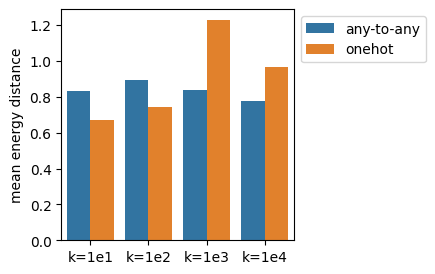

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(3, 3))
sns.barplot(x='Model Config', y='Mean', hue='Model Type', 
            data=df_results[df_results['Metric'] == 'energy'])
plt.legend(loc='upper left', bbox_to_anchor=(1, 1), title='')
plt.ylabel('mean energy distance')
plt.xlabel('')